Loading processed news data...
Analyzing sentiment (this may take a moment)...

--- Correlation Analysis Results ---
AAPL: 0.1628
AMZN: 0.1622
GOOG: 0.1738
META: 0.4503
NVDA: 0.2095


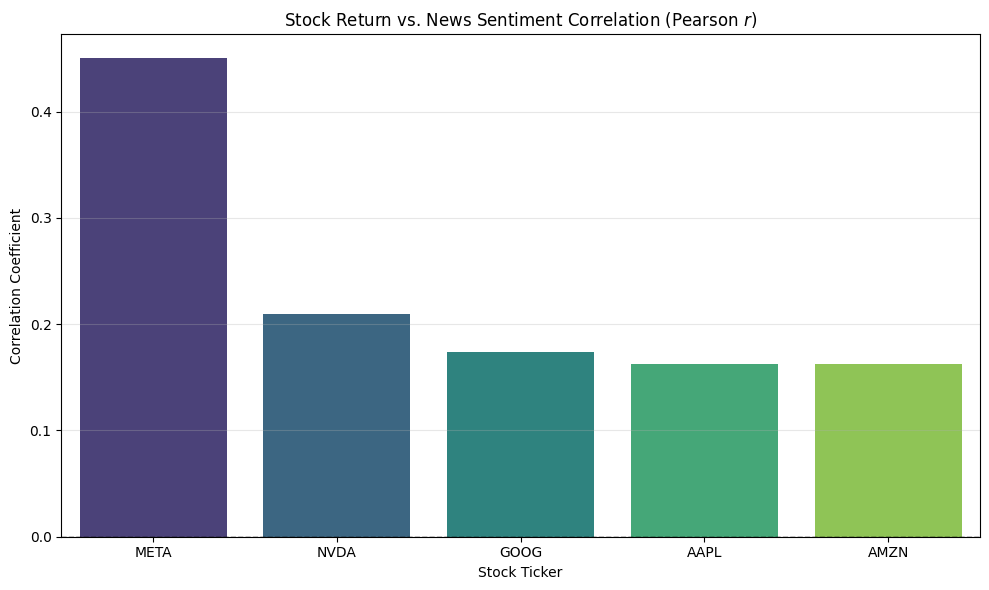

In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. SETUP & PATHS
NEWS_PATH = '../data/processed/cleaned_news_data.csv'
FINANCE_DIR = '../data/processed/finance_data/'
TICKERS = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

# 2. INITIALIZE VADER
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    """Calculates VADER compound score for a headline."""
    if pd.isna(text): return 0
    return analyzer.polarity_scores(str(text))['compound']

# 3. LOAD AND PREPARE NEWS DATA
print("Loading processed news data...")
news_df = pd.read_csv(NEWS_PATH)

news_df['stock'] = news_df['stock'].replace('FB', 'META')
news_df['date'] = pd.to_datetime(news_df['date'])

# Apply VADER Sentiment
print("Analyzing sentiment (this may take a moment)...")
news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment_score)

# 4. WEEKEND ALIGNMENT STRATEGY
news_df['trading_date'] = news_df['date'].dt.date
news_df['day_of_week'] = news_df['date'].dt.dayofweek

# Shift Saturday (5) to Monday (+2) and Sunday (6) to Monday (+1)
news_df.loc[news_df['day_of_week'] == 5, 'trading_date'] += pd.Timedelta(days=2)
news_df.loc[news_df['day_of_week'] == 6, 'trading_date'] += pd.Timedelta(days=1)

# Aggregate daily sentiment per stock
daily_sentiment = news_df.groupby(['trading_date', 'stock'])['sentiment_score'].mean().reset_index()
daily_sentiment['trading_date'] = pd.to_datetime(daily_sentiment['trading_date'])

# 5. CORRELATION LOOP
correlation_results = {}

print("\n--- Correlation Analysis Results ---")

for ticker in TICKERS:
    try:
        # Load processed finance data from Task 2
        stock_path = os.path.join(FINANCE_DIR, f'{ticker}_indicators.csv')
        if not os.path.exists(stock_path):
            print(f"{ticker}: Processed indicator file not found.")
            continue
            
        stock_df = pd.read_csv(stock_path, index_col='Date', parse_dates=True)
        
        # Standardize dates (remove timezones)
        stock_df.index = stock_df.index.tz_localize(None)
        
        # Ensure daily_return exists
        if 'daily_return' not in stock_df.columns:
            price_col = 'target_price' if 'target_price' in stock_df.columns else stock_df.columns[0]
            stock_df['daily_return'] = stock_df[price_col].pct_change()

        # Filter sentiment for THIS ticker
        ticker_sentiment = daily_sentiment[daily_sentiment['stock'] == ticker].copy()
        
        # Merge on trading dates
        merged_df = pd.merge(
            stock_df[['daily_return']], 
            ticker_sentiment[['trading_date', 'sentiment_score']], 
            left_index=True, 
            right_on='trading_date', 
            how='inner'
        )

        if not merged_df.empty:
            corr_value = merged_df['daily_return'].corr(merged_df['sentiment_score'])
            correlation_results[ticker] = corr_value
            print(f"{ticker}: {corr_value:.4f}")
            
            # Export merged data for Task 4 Strategy
            merged_df.to_csv(f'../data/processed/{ticker}_sentiment_merged.csv', index=False)
        else:
            print(f"{ticker}: No overlapping dates found between news and price data.")
            
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

# 6. FINAL VISUALIZATION (Fixing FutureWarning)
if correlation_results:
    plt.figure(figsize=(10, 6))
    summary_series = pd.Series(correlation_results).sort_values(ascending=False)
    
    # Modern Seaborn syntax to avoid warnings
    sns.barplot(
        x=summary_series.index, 
        y=summary_series.values, 
        hue=summary_series.index, 
        palette='viridis', 
        legend=False
    )
    
    plt.title('Stock Return vs. News Sentiment Correlation (Pearson $r$)')
    plt.ylabel('Correlation Coefficient')
    plt.xlabel('Stock Ticker')
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()